<a href="https://colab.research.google.com/github/JasenovichYukopila/Veles/blob/main/Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# 1. Cargar los datos
df = pd.read_csv('dataset_15s_overlap.csv')

In [24]:
# 2. Separar Features (X), Target (y) y Grupos (song_id)
X = df.drop(columns=['label', 'song_id', 'segment_type'])
y = df['label']
groups = df['song_id']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [25]:
# 3. GroupShuffleSplit — mismo random_state que v1 para comparación justa
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=9347234)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

In [26]:
# 4. Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 1er Run de Modelos

In [27]:
# 5. Definir modelos
# ─── Modelos originales ───────────────────────────────────────────────────────
svm_rbf  = SVC(kernel='rbf',    probability=True, random_state=42)
rf       = RandomForestClassifier(n_estimators=100, random_state=42)
gb       = GradientBoostingClassifier(n_estimators=100, random_state=42)

# ─── Nuevos kernels SVM ───────────────────────────────────────────────────────
# Linear: separa con una línea recta, más rápido, mejor en espacios de alta dimensión
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

# Poly: captura interacciones entre features (ej. tempo × chroma)
# degree=3 es el estándar, C=1 regularización por defecto
svm_poly   = SVC(kernel='poly', degree=3, probability=True, random_state=42)

# LinearSVC: versión optimizada del kernel lineal, mucho más rápida en datasets grandes
# Necesita CalibratedClassifierCV para obtener probabilidades
linear_svc = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))

# ─── Voting Classifier (combinación de los mejores) ──────────────────────────
# Combina SVM-Linear + GB + RF: vota por mayoría suave (soft = usa probabilidades)
voting = VotingClassifier(
    estimators=[
        ('svm_linear', SVC(kernel='linear', probability=True, random_state=42)),
        ('gb',         GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('rf',         RandomForestClassifier(n_estimators=100, random_state=42))
    ],
    voting='soft'
)

models = {
    # Originales
    "SVM (RBF)": svm_rbf,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    # Nuevos
    "SVM (Linear)": svm_linear,
    "SVM (Poly)": svm_poly,
    "LinearSVC": linear_svc,
    "Voting (Linear + GB + RF)": voting
}


  Entrenando: SVM (RBF)
Exactitud (Accuracy) Global: 0.6906

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.64      0.67      0.65       155
     Hip-Hop       0.54      0.65      0.59        98
        Rock       0.62      0.71      0.66        86
   Vallenato       0.75      0.61      0.68       129
     clasicc       0.93      0.93      0.93       149
        jazz       0.80      0.83      0.82       177
         pop       0.49      0.42      0.45       169

    accuracy                           0.69       963
   macro avg       0.68      0.69      0.68       963
weighted avg       0.69      0.69      0.69       963



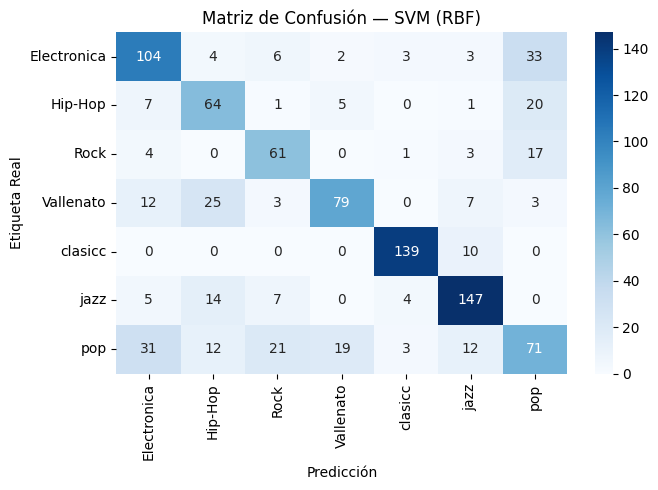


  Entrenando: Random Forest
Exactitud (Accuracy) Global: 0.6563

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.64      0.70      0.67       155
     Hip-Hop       0.49      0.57      0.53        98
        Rock       0.57      0.84      0.68        86
   Vallenato       0.60      0.57      0.58       129
     clasicc       0.95      0.94      0.94       149
        jazz       0.76      0.77      0.76       177
         pop       0.45      0.28      0.34       169

    accuracy                           0.66       963
   macro avg       0.64      0.67      0.64       963
weighted avg       0.65      0.66      0.65       963



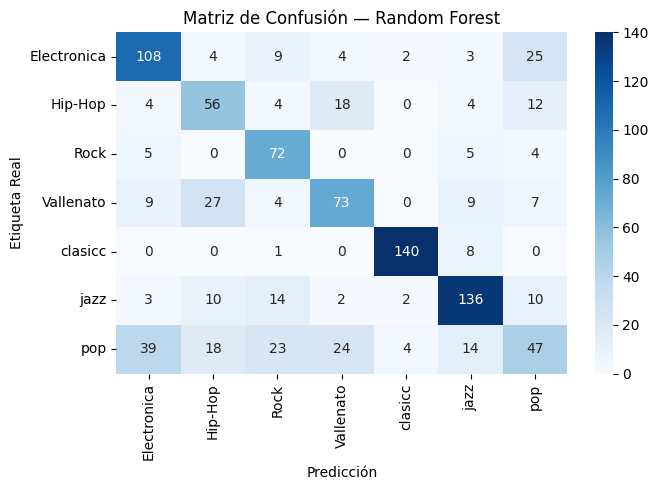


  Entrenando: Gradient Boosting
Exactitud (Accuracy) Global: 0.6791

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.63      0.65      0.64       155
     Hip-Hop       0.59      0.62      0.60        98
        Rock       0.62      0.74      0.67        86
   Vallenato       0.66      0.58      0.62       129
     clasicc       0.95      0.94      0.94       149
        jazz       0.77      0.76      0.77       177
         pop       0.49      0.46      0.48       169

    accuracy                           0.68       963
   macro avg       0.67      0.68      0.67       963
weighted avg       0.68      0.68      0.68       963



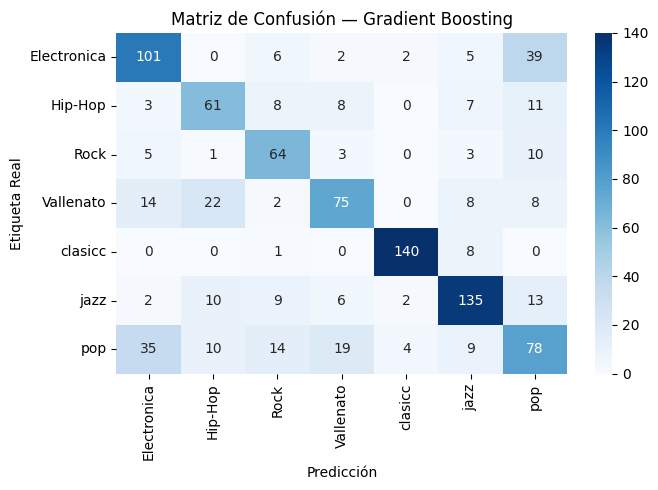


  Entrenando: SVM (Linear)
Exactitud (Accuracy) Global: 0.6729

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.61      0.61      0.61       155
     Hip-Hop       0.53      0.68      0.60        98
        Rock       0.47      0.65      0.55        86
   Vallenato       0.85      0.71      0.78       129
     clasicc       0.93      0.89      0.91       149
        jazz       0.76      0.66      0.71       177
         pop       0.56      0.53      0.54       169

    accuracy                           0.67       963
   macro avg       0.67      0.68      0.67       963
weighted avg       0.69      0.67      0.68       963



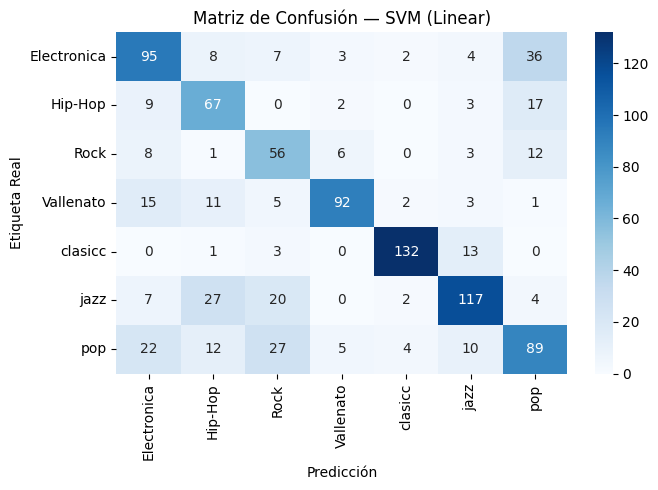


  Entrenando: SVM (Poly)
Exactitud (Accuracy) Global: 0.6189

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.72      0.51      0.60       155
     Hip-Hop       0.58      0.62      0.60        98
        Rock       0.33      0.80      0.47        86
   Vallenato       0.51      0.71      0.59       129
     clasicc       0.95      0.85      0.90       149
        jazz       0.86      0.66      0.74       177
         pop       0.57      0.32      0.41       169

    accuracy                           0.62       963
   macro avg       0.65      0.64      0.62       963
weighted avg       0.68      0.62      0.63       963



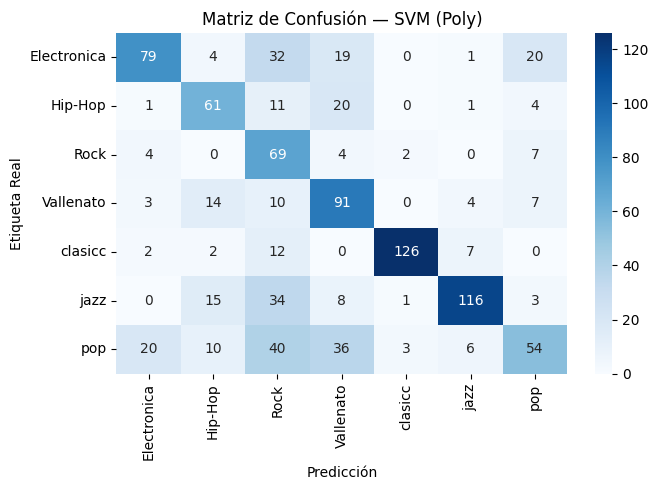


  Entrenando: LinearSVC
Exactitud (Accuracy) Global: 0.6532

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.62      0.63      0.62       155
     Hip-Hop       0.47      0.61      0.53        98
        Rock       0.50      0.72      0.59        86
   Vallenato       0.74      0.60      0.66       129
     clasicc       0.85      0.91      0.88       149
        jazz       0.74      0.69      0.72       177
         pop       0.60      0.44      0.51       169

    accuracy                           0.65       963
   macro avg       0.64      0.66      0.64       963
weighted avg       0.66      0.65      0.65       963



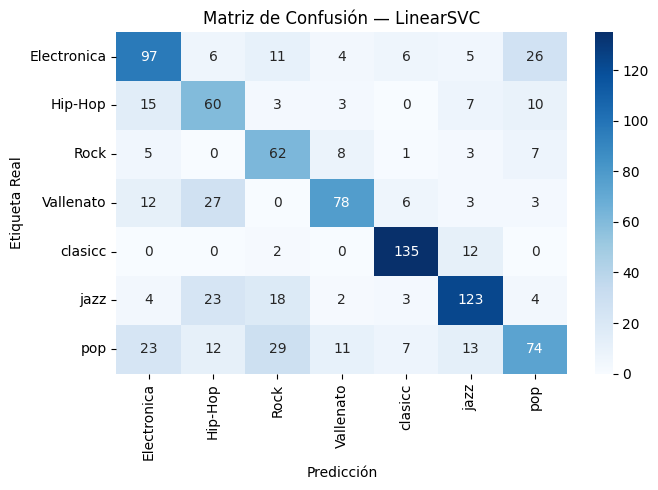


  Entrenando: Voting (Linear + GB + RF)
Exactitud (Accuracy) Global: 0.6947

Reporte de Clasificación:
              precision    recall  f1-score   support

 Electronica       0.67      0.66      0.67       155
     Hip-Hop       0.58      0.64      0.61        98
        Rock       0.62      0.77      0.68        86
   Vallenato       0.70      0.64      0.67       129
     clasicc       0.93      0.93      0.93       149
        jazz       0.80      0.79      0.79       177
         pop       0.49      0.45      0.47       169

    accuracy                           0.69       963
   macro avg       0.69      0.70      0.69       963
weighted avg       0.70      0.69      0.69       963



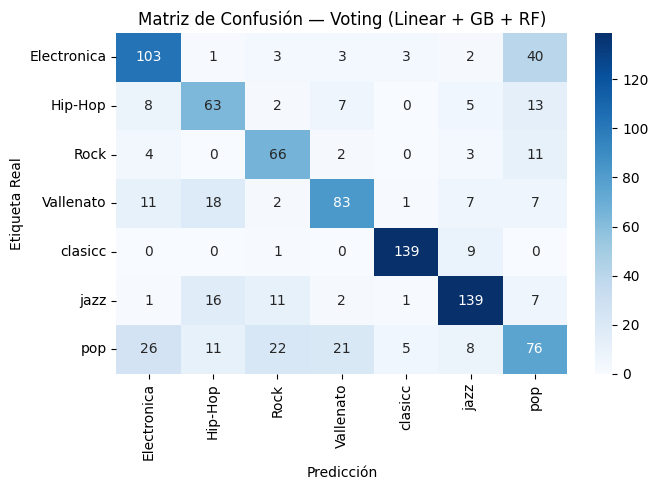

In [28]:
# 6. Entrenamiento, evaluación y comparación
resultados = []  # Para tabla comparativa al final

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Entrenando: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"Exactitud (Accuracy) Global: {acc:.4f}\n")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Guardar para tabla final
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    resultados.append({'Modelo': name, 'Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión — {name}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

In [29]:
# 7. Tabla comparativa final de todos los modelos
df_resultados = pd.DataFrame(resultados).sort_values('Macro F1', ascending=False)
df_resultados = df_resultados.reset_index(drop=True)
df_resultados.index += 1  # Ranking desde 1

print("\n" + "="*50)
print("       RANKING FINAL DE MODELOS")
print("="*50)
print(df_resultados.to_string())
print("="*50)
print("\nMejor modelo por Macro F1:", df_resultados.iloc[0]['Modelo'])


       RANKING FINAL DE MODELOS
                      Modelo  Accuracy  Macro F1
1  Voting (Linear + GB + RF)    0.6947    0.6902
2                  SVM (RBF)    0.6906    0.6827
3          Gradient Boosting    0.6791    0.6749
4               SVM (Linear)    0.6729    0.6701
5                  LinearSVC    0.6532    0.6440
6              Random Forest    0.6563    0.6435
7                 SVM (Poly)    0.6189    0.6155

Mejor modelo por Macro F1: Voting (Linear + GB + RF)


# 2do Run de Modelos

Se ve que el mejor modelo es el ensemble "voting":

1. En el Rock & Pop es donde el modelo esta realmente sufriendo ya que el Rock tiene muy baja precision en 0.37 y muy alto el recall 0.9 lo que nos da a entender que muy probablemente el modelo lo que está haciendo es que lo que no entiende como una clase muy claramente lo manda a rock haciendo que meta rock donde va pero tambien cuando no es y en el Pop sucede que ni la presicion, ni el f1 ni el recall son buenos lo cual puede que suceda porque el pop es un genero que comparte caracteristicas con los demas al tiempo

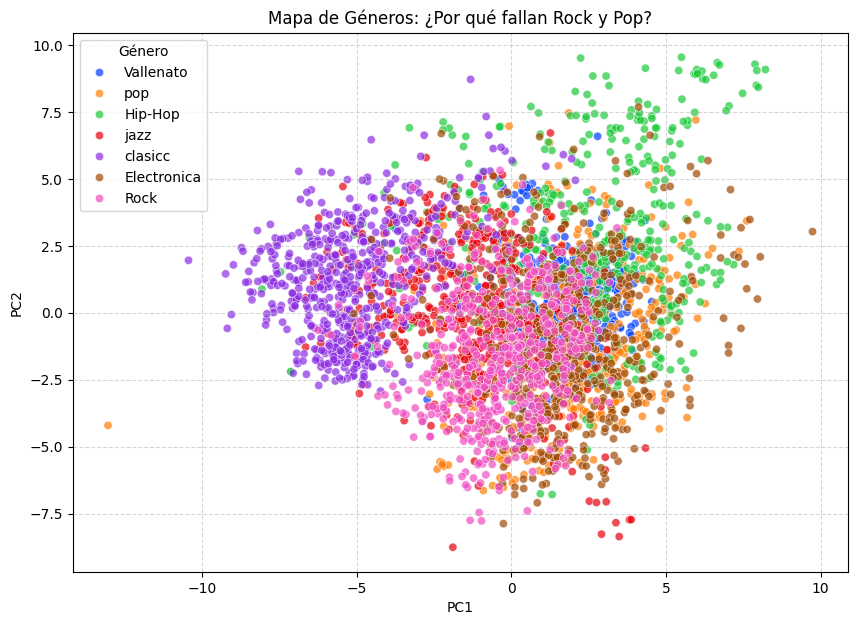

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reducimos a 2 dimensiones para poder graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Creamos un DataFrame para graficar con Seaborn
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Género'] = le.inverse_transform(y_train)

# 3. Graficamos
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Género', alpha=0.7, palette='bright')
plt.title('Mapa de Géneros: ¿Por qué fallan Rock y Pop?')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

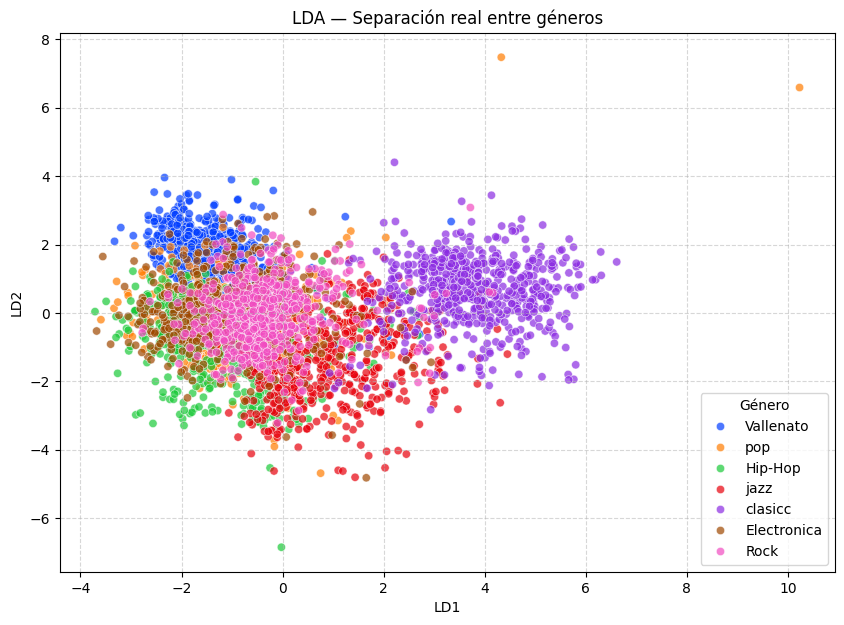

In [31]:
# OPCIÓN A — LDA: la mejor para ver separación real entre clases
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, y_train)  # usa las etiquetas ← clave

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['Género'] = le.inverse_transform(y_train)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_lda, x='LD1', y='LD2', hue='Género', alpha=0.7, palette='bright')
plt.title('LDA — Separación real entre géneros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Vemos que Pop & Rock comparten un gran campo de las caracteristicas por lo que muy probablemente lo que esta sucediendo es que no se diferencian del todo bien,necesitamos o otras caracteristicas o mas datos o algo mas que nos haga realmente diferenciar estos 2 de los demas y entre si. **El punto es mejorar la frontera de decision**

In [32]:
df['label'].value_counts()

,count
label,
clasicc,746
Vallenato,729
jazz,706
Electronica,705
Rock,679
pop,670
Hip-Hop,550


Para eso nos podría servir el **SMOTE (Synthetic Minority Over-sampling Technique)** o

## **SMOTE**

Aunque el Rock y el Pop tengan casi 150 muestras, sus "puntos" en el espacio matemático pueden estar muy dispersos o rodeados de mucho "ruido" de otros géneros.

1. SMOTE no se usa solo para cuando hay "poquitos" datos, sino para densificar las zonas donde el modelo duda. Al crear puntos intermedios entre los datos reales de Rock, estamos rellenando los huecos vacíos en el mapa.

2. Al haber más puntos de Rock y Pop concentrados en sus áreas, los algoritmos como el SVM o el Voting Classifier pueden trazar una "línea de frontera" mucho más precisa y menos zigzagueante.

3. Ayuda a que el modelo no se aprenda de memoria una canción de Rock específica (Overfitting), sino que entienda la "región" donde suele vivir el sonido del Rock.


Antes de SMOTE: Counter({np.int64(3): 600, np.int64(4): 597, np.int64(2): 593, np.int64(0): 550, np.int64(5): 529, np.int64(6): 501, np.int64(1): 452})
Después de SMOTE: Counter({np.int64(3): 600, np.int64(6): 600, np.int64(1): 600, np.int64(5): 600, np.int64(4): 600, np.int64(0): 600, np.int64(2): 600})

  Entrenando con SMOTE: SVM (RBF)
Exactitud (Accuracy): 0.6947
Macro F1-Score: 0.6872

              precision    recall  f1-score   support

 Electronica       0.64      0.65      0.65       155
     Hip-Hop       0.55      0.65      0.60        98
        Rock       0.62      0.71      0.66        86
   Vallenato       0.76      0.60      0.67       129
     clasicc       0.93      0.93      0.93       149
        jazz       0.81      0.84      0.82       177
         pop       0.51      0.46      0.48       169

    accuracy                           0.69       963
   macro avg       0.69      0.69      0.69       963
weighted avg       0.70      0.69      0.69       963



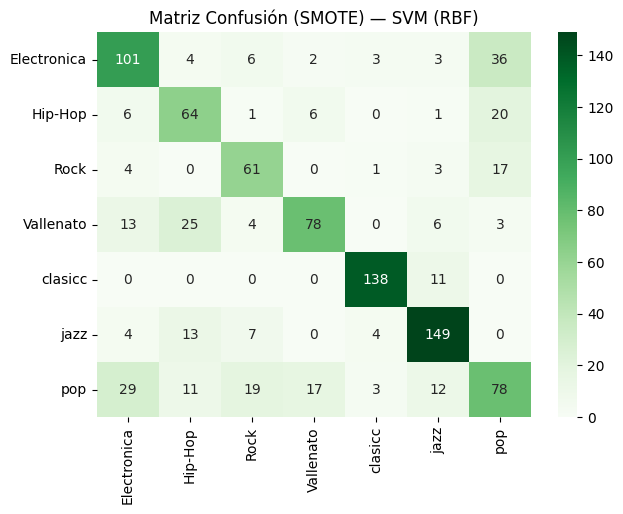


  Entrenando con SMOTE: Random Forest
Exactitud (Accuracy): 0.6615
Macro F1-Score: 0.6522

              precision    recall  f1-score   support

 Electronica       0.63      0.69      0.66       155
     Hip-Hop       0.50      0.59      0.54        98
        Rock       0.58      0.85      0.69        86
   Vallenato       0.62      0.56      0.59       129
     clasicc       0.93      0.93      0.93       149
        jazz       0.78      0.75      0.76       177
         pop       0.48      0.33      0.39       169

    accuracy                           0.66       963
   macro avg       0.65      0.67      0.65       963
weighted avg       0.66      0.66      0.65       963



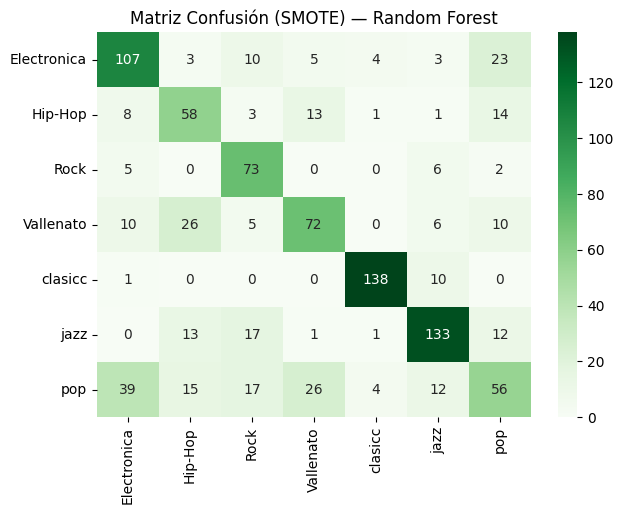


  Entrenando con SMOTE: Gradient Boosting
Exactitud (Accuracy): 0.6656
Macro F1-Score: 0.6634

              precision    recall  f1-score   support

 Electronica       0.63      0.65      0.64       155
     Hip-Hop       0.54      0.59      0.57        98
        Rock       0.64      0.76      0.70        86
   Vallenato       0.65      0.55      0.59       129
     clasicc       0.96      0.93      0.95       149
        jazz       0.77      0.74      0.75       177
         pop       0.45      0.45      0.45       169

    accuracy                           0.67       963
   macro avg       0.66      0.67      0.66       963
weighted avg       0.67      0.67      0.67       963



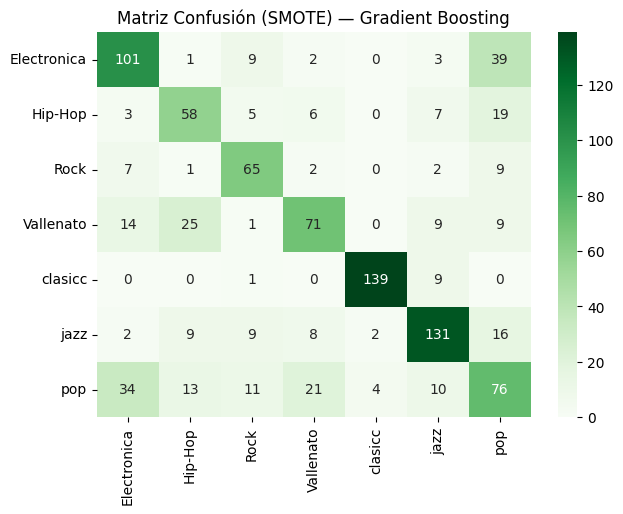


  Entrenando con SMOTE: SVM (Linear)
Exactitud (Accuracy): 0.6667
Macro F1-Score: 0.6655

              precision    recall  f1-score   support

 Electronica       0.60      0.58      0.59       155
     Hip-Hop       0.49      0.69      0.58        98
        Rock       0.50      0.65      0.57        86
   Vallenato       0.89      0.68      0.77       129
     clasicc       0.93      0.87      0.90       149
        jazz       0.75      0.66      0.70       177
         pop       0.55      0.55      0.55       169

    accuracy                           0.67       963
   macro avg       0.67      0.67      0.67       963
weighted avg       0.69      0.67      0.67       963



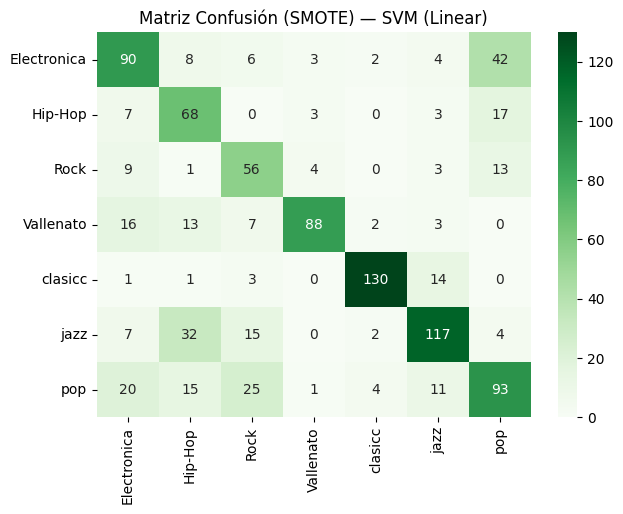


  Entrenando con SMOTE: Voting (Linear + GB + RF)
Exactitud (Accuracy): 0.7061
Macro F1-Score: 0.7020

              precision    recall  f1-score   support

 Electronica       0.68      0.67      0.68       155
     Hip-Hop       0.57      0.67      0.62        98
        Rock       0.62      0.77      0.69        86
   Vallenato       0.75      0.66      0.70       129
     clasicc       0.93      0.93      0.93       149
        jazz       0.81      0.79      0.80       177
         pop       0.52      0.48      0.50       169

    accuracy                           0.71       963
   macro avg       0.70      0.71      0.70       963
weighted avg       0.71      0.71      0.71       963



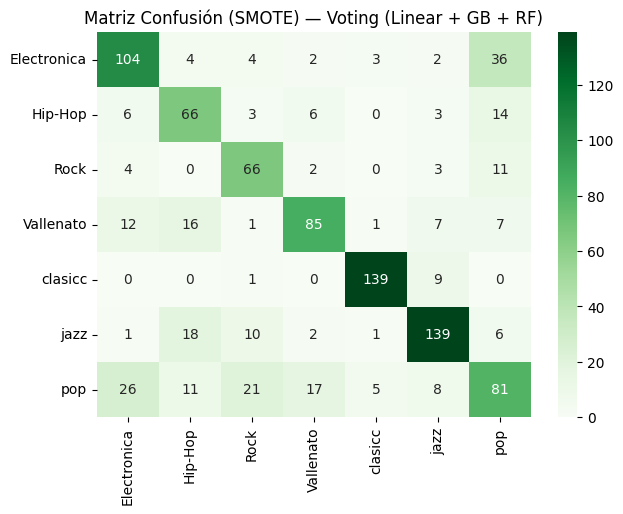

In [33]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df.drop(columns=['label', 'song_id', 'segment_type'])
y = df['label']
groups = df['song_id']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# GroupShuffleSplit (Mantenemos el random_state para que el TEST sea el mismo de antes)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=9347234)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── NUEVO PASO: APLICACIÓN DE SMOTE ─────────────────────────────────────────
# Explicación para clase: Balanceamos el Hip-Hop y densificamos Rock/Pop
print(f"Antes de SMOTE: {Counter(y_train)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Después de SMOTE: {Counter(y_train_res)}")
# ─────────────────────────────────────────────────────────────────────────────

# Definir modelos (Incluyendo los pesos balanceados para mayor robustez)
models = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42),
    "Voting (Linear + GB + RF)": VotingClassifier(
        estimators=[
            ('svm_linear', SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)),
            ('gb',         GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('rf',         RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ],
        voting='soft'
    )
}

# Entrenamiento, evaluación y comparación
resultados_smote = []

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Entrenando con SMOTE: {name}")
    print(f"{'='*55}")

    # IMPORTANTE: Entrenamos con los datos aumentados (res), evaluamos con test REAL
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    resultados_smote.append({'Modelo': name, 'Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Color verde para diferenciarlo
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz Confusión (SMOTE) — {name}')
    plt.show()

Realmente no mejoró mucho asi que veamos cuales son las features que realmente mas estan importando

## FE

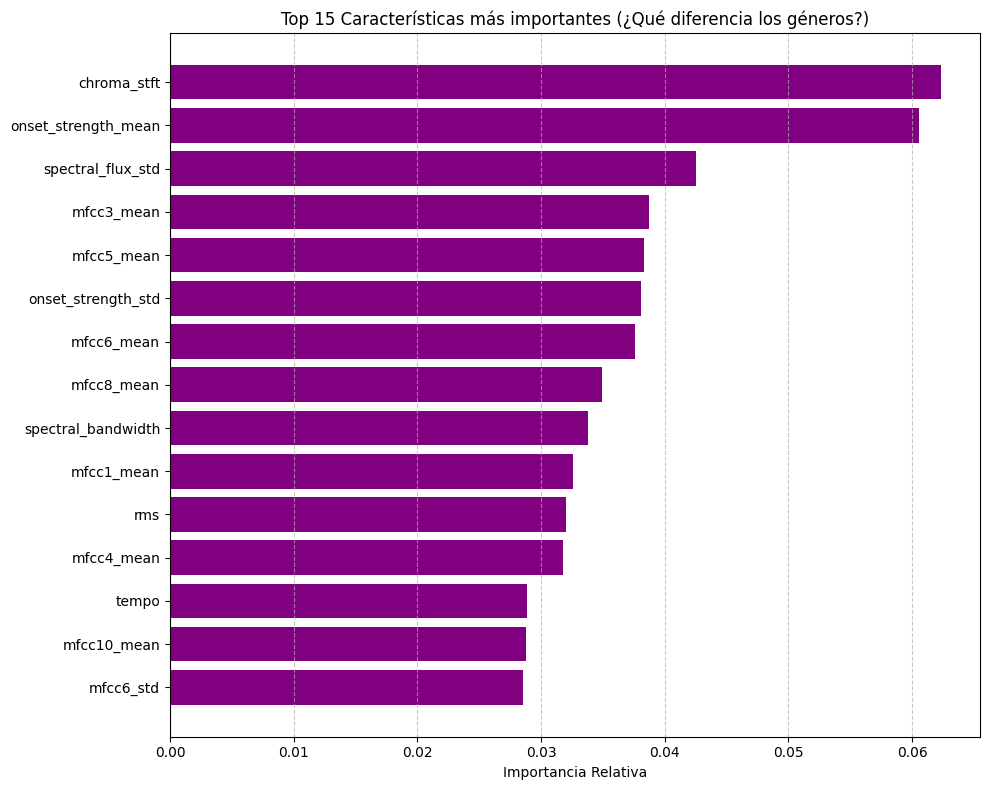

In [34]:
# 1. Entrenamos el Random Forest con los datos de SMOTE
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_res, y_train_res)

# 2. Obtenemos la importancia y la organizamos
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]  # Tomamos las 15 más importantes

# 3. Graficamos
plt.figure(figsize=(10, 8))
plt.title('Top 15 Características más importantes (¿Qué diferencia los géneros?)')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
df.columns

Index(['tempo', 'spectral_centroid', 'spectral_bandwidth', 'rolloff',
       'zero_crossing_rate', 'rms', 'chroma_stft', 'onset_strength_mean',
       'onset_strength_std', 'pitch_variance', 'spectral_flux_std',
       'mfcc1_mean', 'mfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'mfcc3_mean',
       'mfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'mfcc5_mean', 'mfcc5_std',
       'mfcc6_mean', 'mfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'mfcc8_mean',
       'mfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'mfcc10_mean', 'mfcc10_std',
       'mfcc11_mean', 'mfcc11_std', 'mfcc12_mean', 'mfcc12_std', 'mfcc13_mean',
       'mfcc13_std', 'label', 'song_id', 'segment_type'],
      dtype='object')

Algo que llama la atencion es que el **"spectral rolloff"** *(es la frecuencia por debajo de la cual se encuentra el 85% de la energía del espectro. Básicamente, te dice qué tan "brillante" o "agudo" es un sonido.)* que es una de las metricas mas importantes en el paper no para diferenciar al rock no aparece ni si quiera en las 15 mas importantes lo que nos da un indicio de que existe un **solapamiento de brillo** ya que el Pop moderno está tan producido y tiene tantos sintetizadores agudos que su "brillo" (rolloff) es matemáticamente casi igual al de una guitarra distorsionada de Rock. Veamos que tan parecido son estos 2 para Rock y Pop para *verificar la hipotesis*

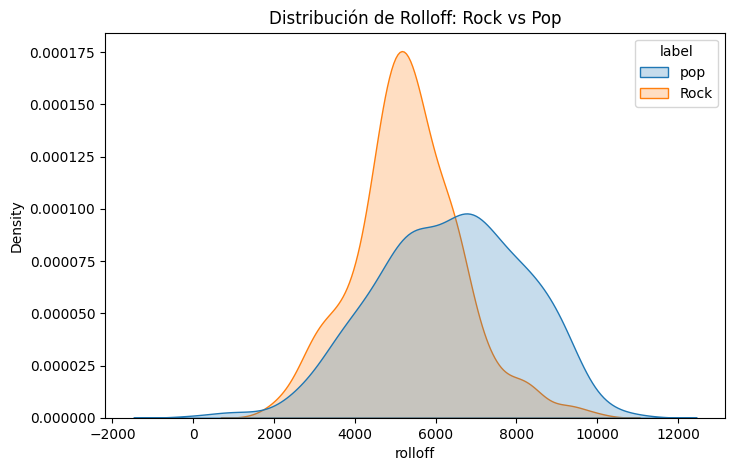

In [36]:
plt.figure(figsize=(8,5))
subset = df[df['label'].isin(['Rock', 'pop'])]
sns.kdeplot(data=subset, x='rolloff', hue='label', fill=True)
plt.title('Distribución de Rolloff: Rock vs Pop')
plt.show()

Viendo que claramente la hipotesis es cierta porque vemos que hay un solapamiento fuertisimo entre las 2 que confunde al modelo, algo que podriamos hacer es hacer que el modelo vea otra forma de relacionar el brillo para que capte la diferencia, lo cual lo podemos hacer creando una nueva feature

In [37]:
df['brightness_ratio'] = df['rolloff'] / (df['spectral_centroid'] + 1e-6)

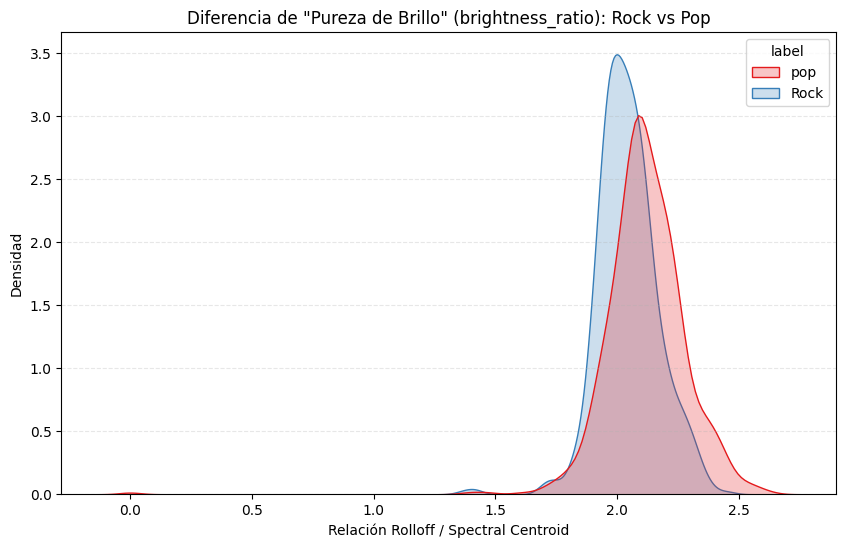

In [38]:
plt.figure(figsize=(10, 6))
# Filtramos solo Rock y Pop para ver el duelo directo
subset = df[df['label'].isin(['Rock', 'pop'])]

sns.kdeplot(data=subset, x='brightness_ratio', hue='label', fill=True, common_norm=False, palette='Set1')
plt.title('Diferencia de "Pureza de Brillo" (brightness_ratio): Rock vs Pop')
plt.xlabel('Relación Rolloff / Spectral Centroid')
plt.ylabel('Densidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Ni aun asi vemos que se quita el solapamiento, de hecho asi es aún peor, por lo que otra cosa que podríamos hacer es quitar el ruido de otras features que no tengan importancia o no esten importando tanto y ver si mejora veamos...

In [39]:
# Suponiendo que ya tienes el rf_model entrenado
importances = rf_model.feature_importances_
feature_names = X.columns
# Ordenamos de menor a mayor
indices_bajos = np.argsort(importances)[:7]

print("Variables con MENOR importancia (Candidatas a ser eliminadas):")
for i in indices_bajos:
    print(f"- {feature_names[i]}: {importances[i]:.4f}")

Variables con MENOR importancia (Candidatas a ser eliminadas):
- mfcc1_std: 0.0121
- mfcc9_std: 0.0129
- mfcc10_std: 0.0133
- mfcc12_std: 0.0142
- mfcc11_std: 0.0156
- mfcc12_mean: 0.0165
- mfcc11_mean: 0.0169


## Optuna+SMOTE+FE

In [40]:
!pip install optuna

[I 2026-05-17 20:15:07,418] A new study created in memory with name: no-name-51fafabf-0cfc-44e5-86fc-d63af5192c50


Iniciando optimización con Optuna (esto puede tardar unos minutos)...


[I 2026-05-17 20:19:40,817] Trial 0 finished with value: 0.8154227587230917 and parameters: {'svc_rbf_c': 2.9384337618838794, 'svc_rbf_gamma': 0.003886325712203456, 'rf_n_estimators': 259, 'rf_max_depth': 26, 'gb_learning_rate': 0.1941298000557087, 'gb_n_estimators': 185}. Best is trial 0 with value: 0.8154227587230917.
[I 2026-05-17 20:23:31,260] Trial 1 finished with value: 0.7949518808756157 and parameters: {'svc_rbf_c': 2.7569590635995476, 'svc_rbf_gamma': 8.676135181425948, 'rf_n_estimators': 376, 'rf_max_depth': 31, 'gb_learning_rate': 0.010542128711231674, 'gb_n_estimators': 172}. Best is trial 0 with value: 0.8154227587230917.
[I 2026-05-17 20:26:06,929] Trial 2 finished with value: 0.8112869814499298 and parameters: {'svc_rbf_c': 0.2275187085186783, 'svc_rbf_gamma': 0.30898951492304044, 'rf_n_estimators': 487, 'rf_max_depth': 20, 'gb_learning_rate': 0.0755638203095836, 'gb_n_estimators': 101}. Best is trial 0 with value: 0.8154227587230917.
[I 2026-05-17 20:28:58,397] Trial 3 


  MEJORES PARÁMETROS ENCONTRADOS
{'svc_rbf_c': 39.826516481938434, 'svc_rbf_gamma': 0.029601260185471313, 'rf_n_estimators': 205, 'rf_max_depth': 47, 'gb_learning_rate': 0.17223491344221578, 'gb_n_estimators': 138}

       REPORTE DE CLASIFICACIÓN FINAL (CON OPTUNA)
Accuracy Global: 0.7196
              precision    recall  f1-score   support

 Electronica       0.63      0.73      0.68       155
     Hip-Hop       0.57      0.70      0.63        98
        Rock       0.72      0.74      0.73        86
   Vallenato       0.80      0.61      0.69       129
     clasicc       0.94      0.93      0.94       149
        jazz       0.84      0.83      0.84       177
         pop       0.54      0.49      0.51       169

    accuracy                           0.72       963
   macro avg       0.72      0.72      0.72       963
weighted avg       0.73      0.72      0.72       963



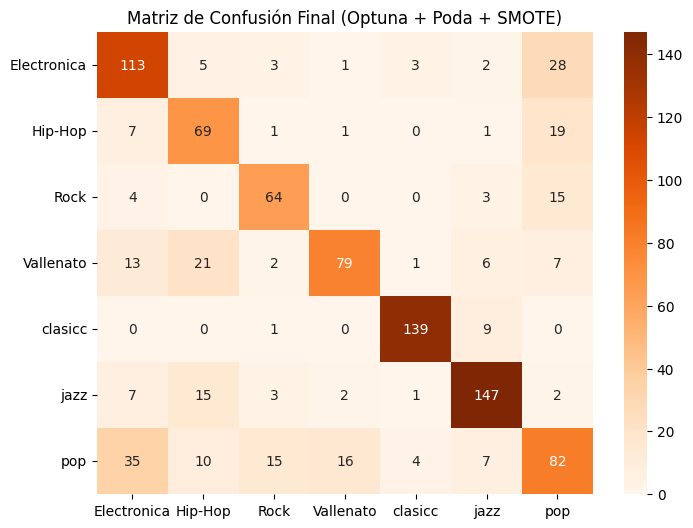

In [41]:
import optuna
from sklearn.model_selection import cross_val_score

# --- CONFIGURACIÓN DE OPTUNA ---

def objective(trial):
    # 1. Sugerencia de hiperparámetros para SVC (RBF)
    svc_rbf_c = trial.suggest_float("svc_rbf_c", 0.1, 100, log=True)
    svc_rbf_gamma = trial.suggest_float("svc_rbf_gamma", 0.001, 10, log=True)

    # 2. Sugerencia para Random Forest
    rf_n_estimators = trial.suggest_int("rf_n_estimators", 100, 500)
    rf_max_depth = trial.suggest_int("rf_max_depth", 10, 50)

    # 3. Sugerencia para Gradient Boosting
    gb_learning_rate = trial.suggest_float("gb_learning_rate", 0.01, 0.3, log=True)
    gb_n_estimators = trial.suggest_int("gb_n_estimators", 50, 200)

    # Definimos el Voting Classifier con los parámetros sugeridos por Optuna
    clf = VotingClassifier(
        estimators=[
            ('svm_linear', SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced', random_state=42)),
            ('svm_rbf',    SVC(kernel='rbf', C=svc_rbf_c, gamma=svc_rbf_gamma, probability=True, class_weight='balanced', random_state=42)),
            ('rf',         RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, class_weight='balanced', random_state=42)),
            ('gb',         GradientBoostingClassifier(n_estimators=gb_n_estimators, learning_rate=gb_learning_rate, random_state=42))
        ],
        voting='soft'
    )

    # Usamos cross_val_score para evaluar la calidad de estos parámetros
    # cv=3 es suficiente para no tardar una eternidad en clase
    score = cross_val_score(clf, X_train_res, y_train_res, n_jobs=-1, cv=3, scoring='f1_macro')
    return score.mean()

# 4. EJECUCIÓN DE LA OPTIMIZACIÓN
print("Iniciando optimización con Optuna (esto puede tardar unos minutos)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20) # Puedes subir n_trials a 50 para más precisión

print("\n" + "="*30)
print("  MEJORES PARÁMETROS ENCONTRADOS")
print("="*30)
print(study.best_params)

# 5. ENTRENAMIENTO DEL MODELO FINAL CON LOS MEJORES PARÁMETROS
best = study.best_params

voting_final_opt = VotingClassifier(
    estimators=[
        ('svm_linear', SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced', random_state=42)),
        ('svm_rbf',    SVC(kernel='rbf', C=best['svc_rbf_c'], gamma=best['svc_rbf_gamma'], probability=True, class_weight='balanced', random_state=42)),
        ('rf',         RandomForestClassifier(n_estimators=best['rf_n_estimators'], max_depth=best['rf_max_depth'], class_weight='balanced', random_state=42)),
        ('gb',         GradientBoostingClassifier(n_estimators=best['gb_n_estimators'], learning_rate=best['gb_learning_rate'], random_state=42))
    ],
    voting='soft'
)

voting_final_opt.fit(X_train_res, y_train_res)

# 6. EVALUACIÓN FINAL
y_pred_opt = voting_final_opt.predict(X_test_scaled)

print("\n" + "="*60)
print("       REPORTE DE CLASIFICACIÓN FINAL (CON OPTUNA)")
print("="*60)
print(f"Accuracy Global: {accuracy_score(y_test, y_pred_opt):.4f}")
print(classification_report(y_test, y_pred_opt, target_names=le.classes_))

# 7. Matriz de Confusión Final
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges', # Color naranja para distinguir la V3
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Final (Optuna + Poda + SMOTE)')
plt.show()

Mejoró Pop sobre todo aunque aun es bastante mejorable y el de rock tam bien pero es aun mas mejorable